In [6]:
# Cell 0.1: Cài đặt thư viện cần thiết (nếu chưa có)
!pip install vnstock keras-tuner tensorflow scikit-learn matplotlib pandas numpy -q

In [1]:
# Cell 0.2: Import các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
from vnstock import Vnstock  # Thư viện lấy dữ liệu chứng khoán Việt Nam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid') # Chọn style cho plot
pd.options.display.float_format = '{:,.2f}'.format # Định dạng số float

Phiên bản Vnstock 3.2.5 đã có mặt, vui lòng cập nhật với câu lệnh : `pip install vnstock --upgrade`.
Lịch sử phiên bản: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban
Phiên bản hiện tại 3.2.4

In [26]:
# Cell 1.3: Làm sạch và chuẩn hóa dữ liệu cơ bản
if not df_raw.empty:
    # Chọn các cột cần thiết và tạo bản sao để tránh SettingWithCopyWarning
    df = df_raw[['time', 'open', 'high', 'low', 'close', 'volume']].copy()

    # Chuyển cột 'time' sang định dạng datetime và đặt làm index
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)

    # Sắp xếp lại theo thời gian (quan trọng cho time series)
    df.sort_index(inplace=True)

    # Xử lý missing values (nếu có - thường ít gặp với OHLCV từ nguồn tốt)
    # Kiểm tra lại sau khi chọn cột
    if df.isnull().sum().sum() > 0:
        print(f"\nPhát hiện {df.isnull().sum().sum()} giá trị thiếu. Sử dụng phương pháp 'forward fill'...")
        df.fillna(method='ffill', inplace=True)
        # Kiểm tra lại sau khi fill
        if df.isnull().sum().sum() == 0:
            print("Đã xử lý xong giá trị thiếu.")
        else:
             print("Vẫn còn giá trị thiếu sau khi fill. Cần kiểm tra lại.")
    else:
        print("\nKhông tìm thấy giá trị thiếu trong các cột đã chọn.")

    # Đảm bảo kiểu dữ liệu số cho các cột giá và khối lượng
    for col in ['open', 'high', 'low', 'close', 'volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce') # Chuyển thành số, lỗi thành NaN

    # Kiểm tra lại NaN sau khi chuyển đổi kiểu dữ liệu
    if df.isnull().sum().sum() > 0:
        print(f"\nPhát hiện {df.isnull().sum().sum()} giá trị không hợp lệ sau khi chuyển đổi kiểu dữ liệu. Sử dụng 'forward fill'...")
        df.fillna(method='ffill', inplace=True)
        df.fillna(method='bfill', inplace=True) # Fill ngược lại nếu giá trị đầu tiên là NaN

    print("\nDữ liệu sau khi làm sạch cơ bản:")
    display(df.head())
    df.info()
else:
    print("Bỏ qua bước làm sạch do không có dữ liệu.")


Không tìm thấy giá trị thiếu trong các cột đã chọn.

Dữ liệu sau khi làm sạch cơ bản:


,open,high,low,close,volume
time,,,,,
2020-01-02,8.10,8.23,8.06,8.21,2849190
2020-01-03,8.31,8.33,8.21,8.23,3476230
2020-01-06,8.19,8.21,8.11,8.11,2609270
2020-01-07,8.13,8.19,8.08,8.13,2684180
2020-01-08,8.06,8.13,8.02,8.02,4163950


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1328 entries, 2020-01-02 to 2025-04-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    1328 non-null   float64
 1   high    1328 non-null   float64
 2   low     1328 non-null   float64
 3   close   1328 non-null   float64
 4   volume  1328 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 62.2 KB


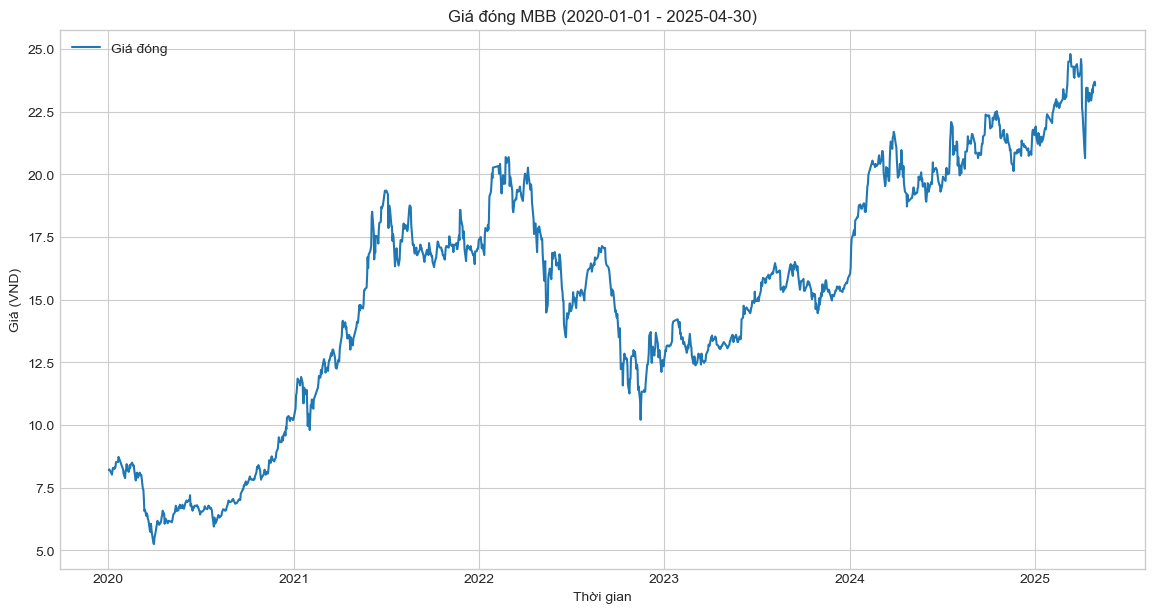

In [28]:
# Cell 1.4: Trực quan hóa dữ liệu giá đóng cửa ban đầu
if not df.empty:
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['close'], label='Giá đóng')
    plt.title(f'Giá đóng {STOCK_SYMBOL} ({START_DATE} - {END_DATE})')
    plt.xlabel('Thời gian')
    plt.ylabel('Giá (VND)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Không có dữ liệu để vẽ biểu đồ.")

In [30]:
# Cell 1.5: Feature Engineering - Tạo các chỉ báo kỹ thuật

if not df.empty:
    print("\nĐang tạo các chỉ báo kỹ thuật...")
    # 1. Moving Averages (MA)
    df['MA5'] = df['close'].rolling(window=5).mean()
    df['MA20'] = df['close'].rolling(window=20).mean()

    # 2. Relative Strength Index (RSI)
    def calculate_rsi(data, window=14):
        delta = data.diff()
        gain = delta.where(delta > 0, 0).fillna(0)
        loss = -delta.where(delta < 0, 0).fillna(0)

        avg_gain = gain.rolling(window=window, min_periods=1).mean()
        avg_loss = loss.rolling(window=window, min_periods=1).mean()

        # Sử dụng rolling mean thay vì EWM cho RSI chuẩn
        # avg_gain = gain.ewm(com=window-1, adjust=False).mean()
        # avg_loss = loss.ewm(com=window-1, adjust=False).mean()


        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))
        # Xử lý trường hợp avg_loss = 0 (RSI = 100)
        rsi = rsi.replace([np.inf, -np.inf], 100)
        # Xử lý trường hợp ban đầu là NaN nếu avg_loss và avg_gain cùng là 0
        rsi = rsi.fillna(50) # Giá trị trung tính ban đầu
        return rsi

    df['RSI'] = calculate_rsi(df['close'])

    # 3. Moving Average Convergence Divergence (MACD)
    def calculate_macd(data, fast=12, slow=26, signal=9):
        exp1 = data.ewm(span=fast, adjust=False).mean()
        exp2 = data.ewm(span=slow, adjust=False).mean()
        macd = exp1 - exp2
        signal_line = macd.ewm(span=signal, adjust=False).mean()
        return macd, signal_line

    df['MACD'], df['Signal_Line'] = calculate_macd(df['close'])

    # 4. Phần trăm thay đổi giá đóng cửa so với ngày trước
    df['Price_Change'] = df['close'].pct_change()

    # 5. Volatility - Độ biến động (Standard Deviation) của giá đóng cửa trong N ngày
    df['Volatility'] = df['close'].rolling(window=5).std()

    # Xóa các dòng có giá trị NaN được tạo ra bởi rolling/diff functions
    initial_rows = len(df)
    df.dropna(inplace=True)
    removed_rows = initial_rows - len(df)
    print(f"Đã xóa {removed_rows} dòng chứa NaN sau khi tạo features.")

    print("\nDữ liệu sau khi thêm features:")
    display(df.head())
    display(df.tail())
else:
    print("Bỏ qua Feature Engineering do không có dữ liệu.")


Đang tạo các chỉ báo kỹ thuật...
Đã xóa 19 dòng chứa NaN sau khi tạo features.

Dữ liệu sau khi thêm features:


,open,high,low,close,volume,MA5,MA20,RSI,MACD,Signal_Line,Price_Change,Volatility
time,,,,,,,,,,,,
2020-02-05,8.29,8.37,8.15,8.19,7177000,8.11,8.28,51.08,-0.01,0.03,0.00,0.14
2020-02-06,8.19,8.52,8.10,8.44,12119010,8.15,8.29,53.81,0.01,0.02,0.03,0.21
2020-02-07,8.42,8.44,8.29,8.29,8050600,8.20,8.29,50.96,0.01,0.02,-0.02,0.21
2020-02-10,8.17,8.25,8.11,8.13,6111600,8.25,8.29,45.37,-0.01,0.02,-0.02,0.12
2020-02-11,8.17,8.25,8.15,8.21,4331600,8.25,8.30,47.75,-0.01,0.01,0.01,0.12


,open,high,low,close,volume,MA5,MA20,RSI,MACD,Signal_Line,Price_Change,Volatility
time,,,,,,,,,,,,
2025-04-23,23.45,23.70,23.10,23.40,33860600,23.14,23.10,44.17,-0.11,-0.17,0.01,0.19
2025-04-24,23.40,23.40,23.05,23.25,18099100,23.19,23.06,54.55,-0.09,-0.16,-0.01,0.17
2025-04-25,23.50,23.75,23.30,23.55,40711200,23.25,23.05,58.21,-0.05,-0.14,0.01,0.24
2025-04-28,23.80,23.85,23.55,23.70,23070500,23.40,23.04,76.42,-0.00,-0.11,0.01,0.24
2025-04-29,23.70,23.75,23.55,23.55,13178800,23.49,23.01,77.88,0.02,-0.08,-0.01,0.17


In [32]:
# Cell 1.6: Chuẩn hóa dữ liệu (Scaling)
if not df.empty:
    print("\nChuẩn hóa dữ liệu sử dụng MinMaxScaler...")
    # Chọn các features sẽ sử dụng cho mô hình
    data_to_scale = df[FEATURES].copy()

    # Khởi tạo scaler
    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit và transform dữ liệu
    scaled_data = scaler.fit_transform(data_to_scale)

    # Tạo dataframe từ dữ liệu đã chuẩn hóa để dễ xem (không bắt buộc)
    scaled_df = pd.DataFrame(scaled_data, columns=FEATURES, index=data_to_scale.index)

    print("Dữ liệu sau khi chuẩn hóa (5 dòng đầu):")
    display(scaled_df.head())

    # Lưu scaler để sử dụng sau này khi giải mã dự đoán
    # (Trong Colab, biến scaler vẫn tồn tại, nhưng nếu chạy script riêng thì cần lưu)
    # import joblib
    # joblib.dump(scaler, 'minmax_scaler_vhc.gz')
else:
    print("Bỏ qua Scaling do không có dữ liệu.")


Chuẩn hóa dữ liệu sử dụng MinMaxScaler...
Dữ liệu sau khi chuẩn hóa (5 dòng đầu):


,close,open,high,low,volume,MA5,MA20,RSI,MACD,Signal_Line,Price_Change,Volatility
time,,,,,,,,,,,,
2020-02-05,0.15,0.16,0.15,0.16,0.07,0.14,0.13,0.49,0.49,0.51,0.50,0.08
2020-02-06,0.16,0.15,0.16,0.15,0.13,0.14,0.13,0.52,0.49,0.51,0.72,0.12
2020-02-07,0.16,0.16,0.15,0.16,0.08,0.14,0.13,0.49,0.49,0.51,0.37,0.12
2020-02-10,0.15,0.15,0.14,0.15,0.06,0.15,0.13,0.43,0.49,0.50,0.36,0.07
2020-02-11,0.15,0.15,0.14,0.16,0.04,0.15,0.13,0.45,0.49,0.50,0.57,0.07


In [34]:
# Cell 1.7: Tạo chuỗi dữ liệu (Sequences) cho LSTM
if 'scaled_data' in locals() and scaled_data.shape[0] > SEQUENCE_LENGTH:
    # Hàm tạo sequences
    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(len(data) - seq_length):
            # Lấy seq_length điểm dữ liệu làm input (X)
            X.append(data[i : i + seq_length])
            # Lấy giá đóng cửa (cột 0) của điểm dữ liệu ngay sau chuỗi làm output (y)
            y.append(data[i + seq_length, 0])
        return np.array(X), np.array(y)

    print(f"\nTạo sequences với độ dài {SEQUENCE_LENGTH} ngày...")
    X, y = create_sequences(scaled_data, SEQUENCE_LENGTH)

    print(f"Kích thước dữ liệu X (sequences): {X.shape}") # (số lượng sequence, độ dài sequence, số features)
    print(f"Kích thước dữ liệu y (targets): {y.shape}") # (số lượng sequence,)
else:
    print("Không đủ dữ liệu để tạo sequences hoặc dữ liệu chưa được chuẩn hóa.")


Tạo sequences với độ dài 60 ngày...
Kích thước dữ liệu X (sequences): (1249, 60, 12)
Kích thước dữ liệu y (targets): (1249,)
